# Data Preprocessing For Gold Price Forecasting
The **Gold Price Forecasting** is a machine learning project focused on forecasting future gold prices using historical market data and relevant economic indicators. The model leverages time-series features such as past gold prices, USD index, crude oil prices, stock market indices, and inflation-related variables to identify patterns and trends.

# **Import Libraries**

In [1]:
# import libraries
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# **Load Dataset**

In [2]:
# reading file path
file = Path(r"../data/price_data.csv")

# reading csv file
df = pd.read_csv(file)

In [3]:
# testing dataset
df.head(10)

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180000,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285000,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167000,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053000,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590000,1.557099
5,1/9/2008,1409.130005,86.550003,75.250000,15.520000,1.466405
6,1/10/2008,1420.329956,88.250000,74.019997,16.061001,1.480100
7,1/11/2008,1401.020020,88.580002,73.089996,16.077000,1.479006
8,1/14/2008,1416.250000,89.540001,74.250000,16.280001,1.486900
9,1/15/2008,1380.949951,87.989998,72.779999,15.834000,1.480210


In [4]:
# shape of the dataset
rows, col = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {col}")

Number of rows: 2290
Number of columns: 6


# **Sanity Check**

In [5]:
# quick overview of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [6]:
# dataset description
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [7]:
#  dataset columns
df.columns

Index(['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'], dtype='object')

In [8]:
# converting date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')

In [9]:
df['Date'].head()

0   2008-01-02
1   2008-01-03
2   2008-01-04
3   2008-01-07
4   2008-01-08
Name: Date, dtype: datetime64[ns]

## **Check for Duplicates**

In [10]:
# check duplicates values
df.duplicated().sum()

0

## **Check for null values**

In [11]:
df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [12]:
# parse date and set it as index
df = df.set_index('Date').sort_index()
df.index.name

'Date'

# **Exploratory Data Analysis (EDA)**

In [13]:
# Set style
sns.set(style="whitegrid")

## **Univariate Analysis**

### **Analyze the Target Variable**

#### ***Trend & Volatility check***

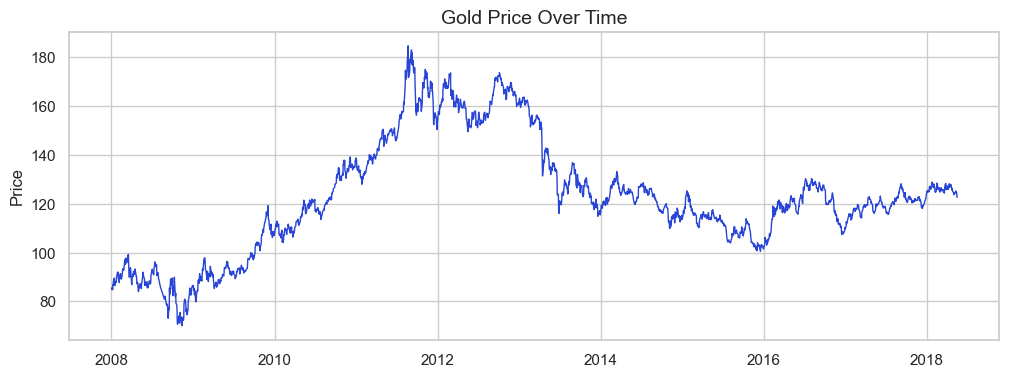

In [14]:
# plot sizing
plt.figure(figsize=(12, 4))

# Time Series Plot
plt.plot(df.index, df['GLD'], linewidth=1, color='#2845D6')
plt.title('Gold Price Over Time', fontsize=14)
plt.ylabel('Price')
plt.show()

#### **Plot Analysis**

**Key Observations**
- Time Period: 2008 to 2018 (~10 years)
- Price Range: ~$70 to ~$185
- Clear Trend Phases:
    - 2008-2011: Strong upward trend (bull market)
    - 2011-2012: Peak around $180-185
    - 2012-2016: Downward trend (bear market)
    - 2016-2018: Sideways/stable consolidation
- Volatility: Visible price fluctuations throughout, especially during 2008-2012

**Key Takeaways**
- Non-Stationary Data: Clear trend present
- Structural Breaks: Major shift around 2011-2012 (likely due to financial crisis aftermath)
- Time-Dependent: Price at time `t` is clearly influenced by previous periods
- Problem for ML Models: Most traditional ML models assume independent observations, but this shows strong temporal dependency

**Decisions/Actions**
- DO NOT NEED TO: feed raw price directly to ML models
- NEED TO: Create stationary series
- NEED TO: Add time-based features or lag features
- NEED TO: Consider log transformation to stabilize variance

#### ***Stationarity Check***

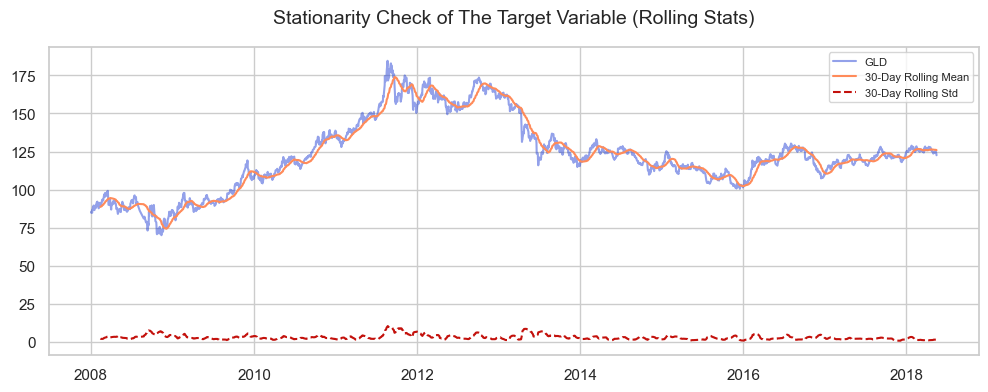

In [15]:
# plot sizing
plt.figure(figsize=(12, 4))

# Rolling Mean & Std
rolling_mean = df['GLD'].rolling(window=30).mean()
rolling_std = df['GLD'].rolling(window=30).std()

plt.plot(df.index, df['GLD'], label='GLD', alpha=0.5, color='#2845D6')
plt.plot(df.index, rolling_mean, label='30-Day Rolling Mean', color='#FF8B5A')
plt.plot(df.index, rolling_std, label='30-Day Rolling Std', color='#C3110C', linestyle='--')
plt.title('Stationarity Check of The Target Variable (Rolling Stats)', fontsize=14, y=1.05)
plt.legend(fontsize=8)
plt.show()

#### **Plot Analysis**

**Key Observations**
-  Rolling Mean (Orange Line):
    - NOT constant - follows the same trend as price
    - Rises from ~$85 (2008) to ~$170 (2012)
    - Falls to ~$120 (2016)
    - Slight rise toward 2018
- Rolling Std (Red Dashed Line):
    - NOT constant - changes over time
    - 2008-2011: Low volatility (~$2-5)
    - 2011-2012: Spike in volatility (~$8-10) ← Market stress period
    - 2013-2018: Lower but variable volatility (~$3-5)

**Key Takeaways**
- CONFIRMED NON-STATIONARY:
    - Mean is time-dependent (violates stationarity assumption)
    - Variance changes over time (heteroscedasticity)
- Violates ARIMA/Traditional Time Series Assumptions
    - These models require stationarity
- Volatility Clustering: High volatility periods cluster together (2011-2012), typical of financial data
- Spurious Regression Risk
    - Using non-stationary data can lead to false correlations

**Decisions/Actions**
- MUST DIFFERENCE the data (1st order differencing) to remove trend
- CONSIDER LOG transformation before differencing to stabilize variance
- TEST formally with Augmented Dickey-Fuller (ADF) test after visual inspection
- For ML Models: Use returns (% change) instead of raw prices
- For Time Series Models: Use differenced series or model the trend explicitly

#### ***Autocorrelation Function (ACF)***

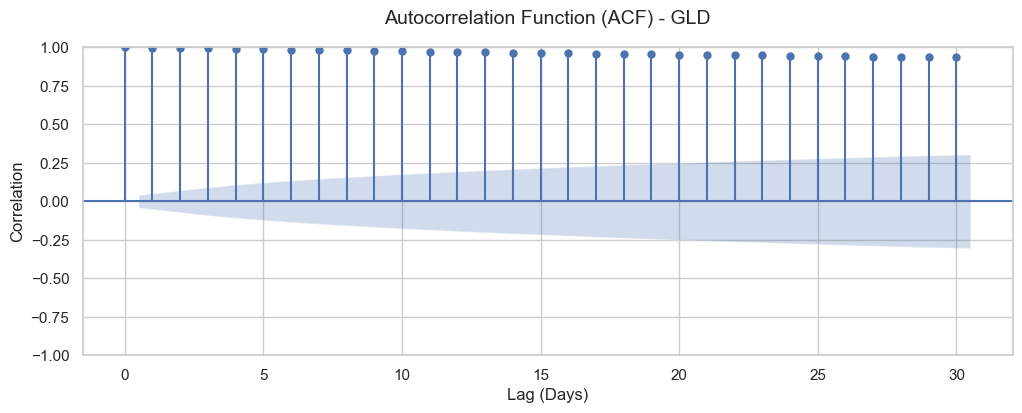

In [16]:
# plot sizing
plt.figure(figsize=(12, 4))

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['GLD'], lags=30, ax=plt.gca(), alpha=0.05)
plt.title('Autocorrelation Function (ACF) - GLD', fontsize=14, y=1.05)
plt.xlabel('Lag (Days)')
plt.ylabel('Correlation')
plt.show()

#### **Plot Analysis**

**Key Observations**
- All lags (0-30) show correlation ≈ 1.0 (extremely high)
- No decay pattern - correlations stay near 1.0 across all 30 days
- All bars well above confidence interval (shaded blue area)
- Slow/No decay indicates strong persistence

**Key Takeaways**
- Classic Non-Stationary Signature:
    - This is the textbook ACF pattern for a non-stationary series with a trend
    - Each day's price is almost perfectly correlated with previous days
    - The series has `long memory` - past values strongly influence future values
- Implications:
    - Random Walk Behavior: Price today ≈ Price yesterday + small change
    - Spurious Correlation Risk: High autocorrelation can create false patterns
    - Model Violation: ARIMA and many statistical models assume ACF decays to zero
- What This Confirms:
    - Visual inspection (rolling stats) was correct - data is non-stationary
    - Differencing is MANDATORY before modeling
    - After 1st differencing, ACF should drop to near-zero quickly

**Decisions/Actions**
- For Time Series Models:
    - Apply 1st order differencing (d=1)
    - After differencing, ACF should show quick decay
- For ML Models:
    - Use returns instead of raw prices
    - This automatically removes the autocorrelation
- For Both Approaches:
    - DO NOT use raw GLD prices as target
    - Transform to stationary series first

#### ***Data Distributiion and Outliers Check***

In [17]:
# Define plot configurations
plots = [
    {
        "func": sns.histplot,
        "kwargs": {"data": df, "x": "GLD", "kde": True, "color": "#2845D6"},
        "title": "GLD Distribution",
        "xlabel": "Price"
    },
    {
        "func": sns.boxplot,
        "kwargs": {"x": df["GLD"], "color": "#28D68D"},
        "title": "GLD Outliers Check",
        "xlabel": None
    }
]

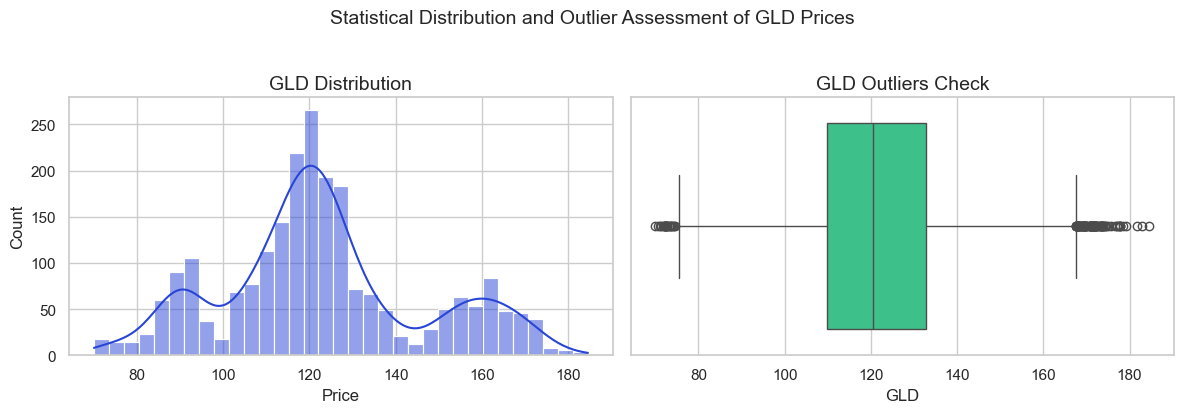

In [18]:
# plot figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loop through axes and plot configurations
for ax, plot in zip(axes, plots):
    plot["func"](ax=ax, **plot["kwargs"])
    ax.set_title(plot["title"], fontsize=14)
    
    if plot["xlabel"]:
        ax.set_xlabel(plot["xlabel"])

plt.suptitle("Statistical Distribution and Outlier Assessment of GLD Prices", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

#### **Plot Analysis**

**Key Observations**

Data Distribution For Density:
- Multi-Modal Distribution: Three distinct peaks visible:
    - Peak 1: ~$90-95 (2008-2009 period)
    - Peak 2: ~$120 (main concentration - 2010, 2016-2018)
    - Peak 3: ~$160-165 (2011-2012 peak period)
- NOT Normal: Clear violation of Gaussian distribution
- Wide Spread: Range from ~$70 to ~$185
- KDE Curve: Confirms the multi-modal pattern

Box Plot For Outliers:
- Outliers Present: Multiple outliers on both ends
    - Lower outliers: ~$70-80 range (2008 crisis lows)
    - Upper outliers: ~$170-185 range (2011-2012 peaks)
- Wide IQR: Large interquartile range indicates high variability
- Long Whiskers: Extended range confirms non-stationarity

**Key Takeaways**
- Multi-Modality = **`Non-Stationarity Confirmed`**:
    - Each mode represents a different market regime
    - This is a direct consequence of the trend we observed earlier
    - The price `lived` in different ranges at different times
- Outliers are NOT Errors:
    - These are real market events (financial crisis, gold rush)
    - DO NOT remove - they contain valuable information
    - They represent structural breaks in the series
- Distribution Implications:
    - Violates normality assumption of many statistical models
    - Raw prices are unsuitable for modeling
    - After transformation (returns/differencing), distribution should normalize
- Critical Insight: The multi-modal distribution is expected for non-stationary price data. Once we convert to returns, we should see a single mode, near normal distribution centered around 0.

**Decisions/Actions**
- DO:
    - Transform to returns or differenced series (this will normalize the distribution)
    - Keep outliers (they're real events)
    - Use robust scaling (not standard scaling) if needed
- DO NOT:
    - Remove outliers (we'll lose critical market event information)
    - Use raw prices for modeling
    - Apply standard normalization on raw prices

### **Analyze The Features**

In [19]:
# exclude target variable
features = [col for col in df.columns if col != 'GLD']

# set grid size dynamically
# ceil division for rows
rows = (len(features) + 1) // 2
cols = 2

#### ***Trend & Volatility check***

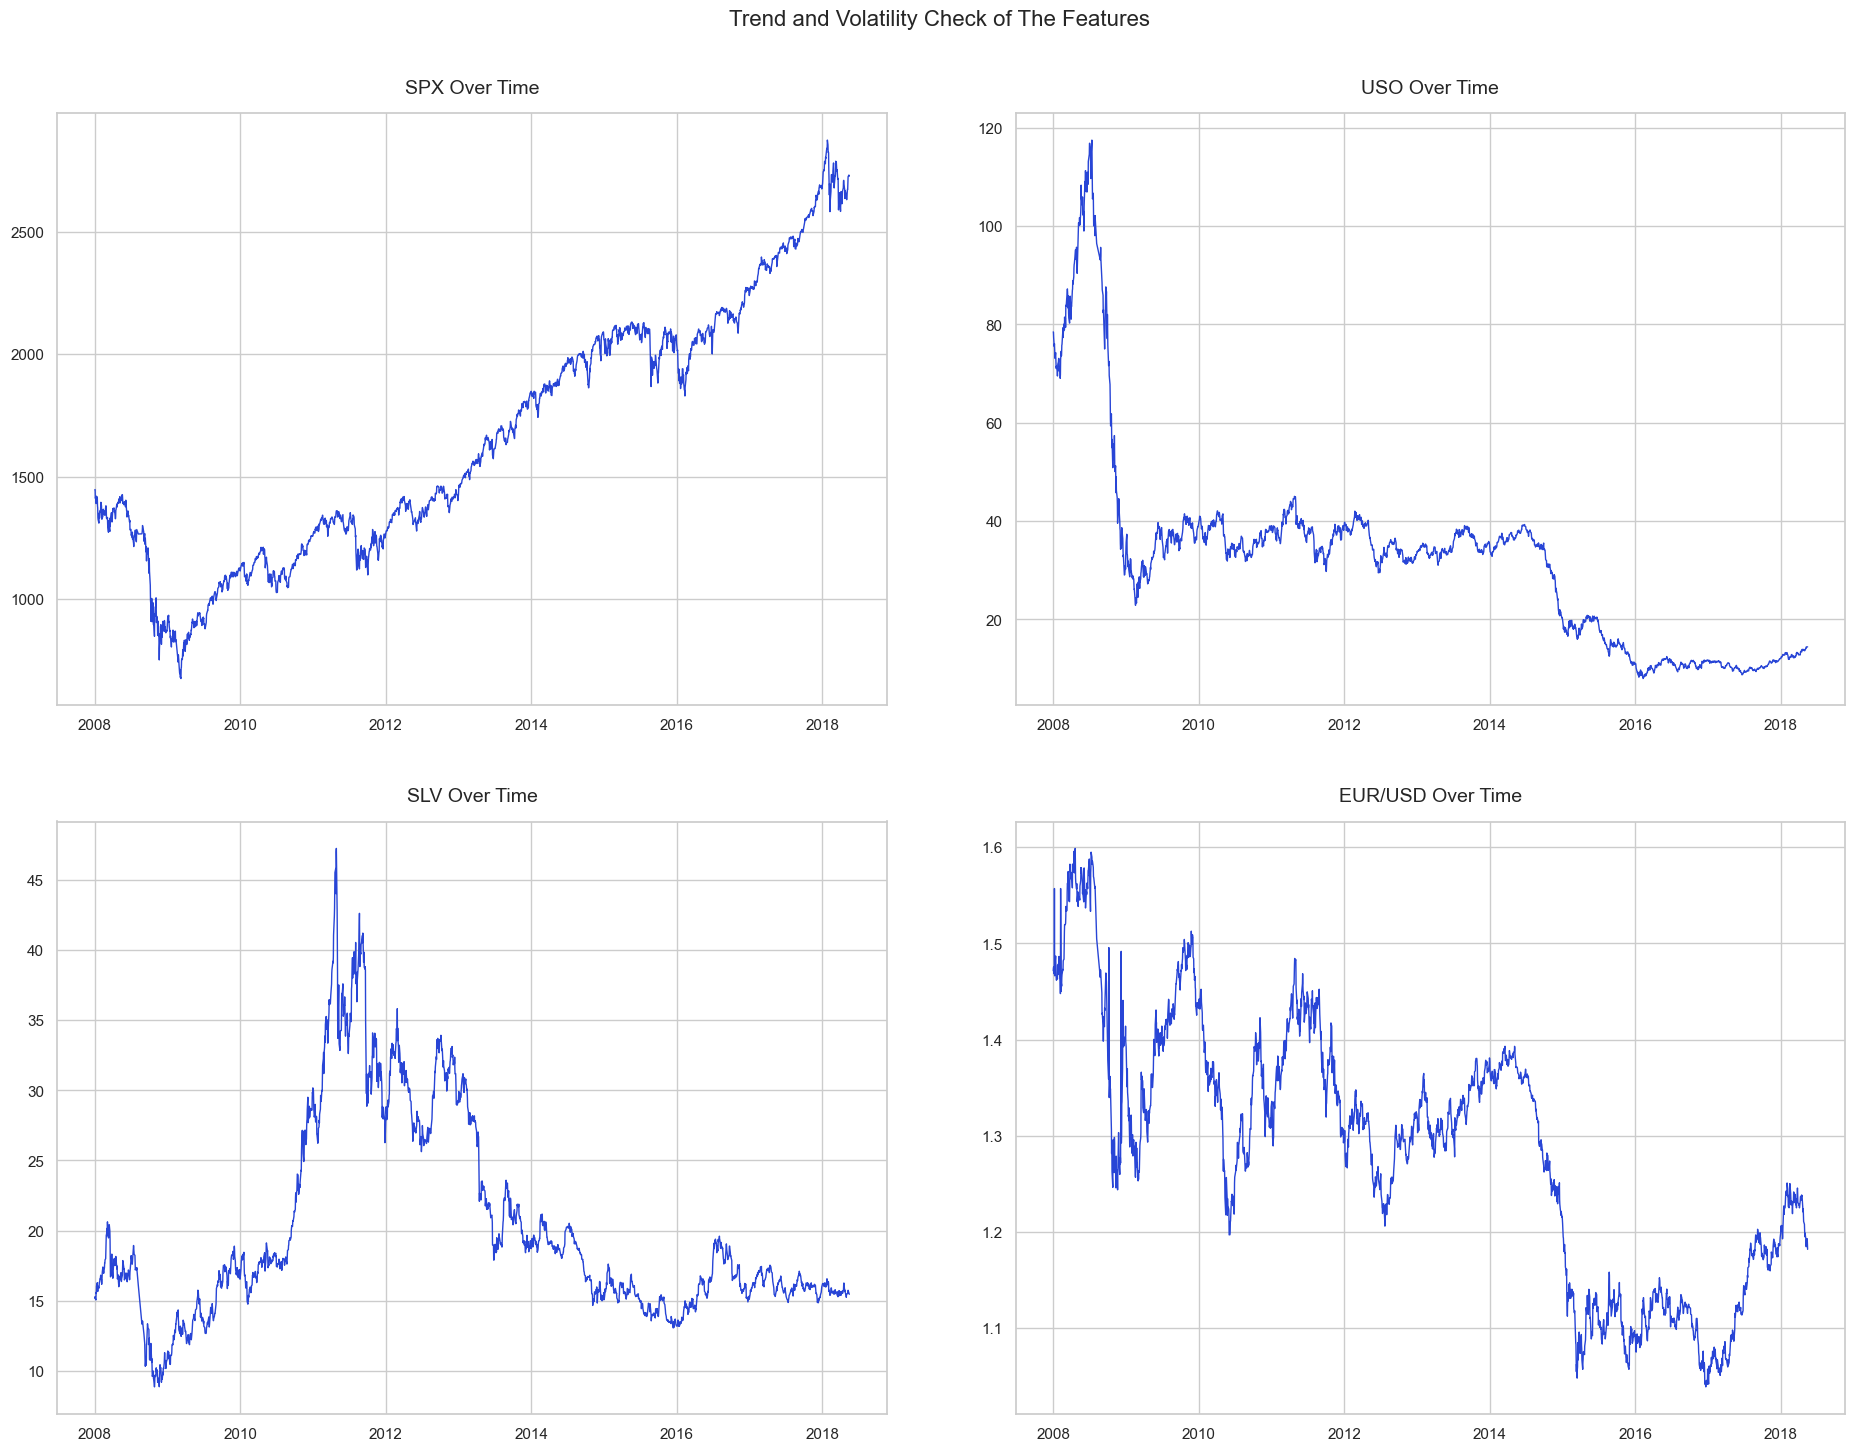

In [20]:
# create subplots
# flatten to 1D for easy indexing
fig, axes = plt.subplots(rows, cols, figsize=(20, 15))
axes = axes.flatten()

fig.tight_layout(pad=5.0)
fig.suptitle('Trend and Volatility Check of The Features', fontsize=16, y=1.01)

# Time-Series Plot
for i, col in enumerate(features):
    axes[i].plot(df.index, df[col], linewidth=1, color='#2845D6')
    axes[i].set_title(f"{col} Over Time", fontsize=14, y=1.02)

# remove unused subplots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.show()

## **Bivariate Analysis**

## **Multivariate Analysis**

# **Outliers Treatment**

# **Feature Engineering**

# Save Data Before Modeling

In [ ]:
# save the output in csv format
file = Path(r"../data/CleanedLoanData.csv")
df.to_csv(file, index=False)